## Common blocks -- run the four code cells below first

Ring of `N` sites (periodic), hopping `t`, on-site `U`, nearest-neighbour `V`. Argument order is always `(N, t, U, V, ...)`; functions restricted to the plain Hubbard ring (`V = 0`) take `(N, t, U, ...)`.


In [1]:
# ==========================================================
# COMMON 1/4 -- imports and plotting style
# ==========================================================
import itertools
import time

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import coo_matrix
from scipy.sparse.linalg import eigsh
from scipy.optimize import brentq, root_scalar

# PRB-style figure defaults (previously set inside the "main-text figures" cell)
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 12,
    "lines.linewidth": 2.5,
    "lines.markersize": 8,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": '--',
})

In [2]:
# ==========================================================
# COMMON 2/4 -- exact diagonalization (periodic ring, extended Hubbard)
#   H = -t sum_<ij>,s c+_is c_js + U sum_i n_iu n_id + V sum_<ij> n_i n_j
#   Bit layout of a determinant: (up, down) integers, bits 0..N-1 = sites.
# ==========================================================
def sector_basis(N, n_up, n_down):
    """All (up, down) determinants with fixed (n_up, n_down). Returns (basis, idx)."""
    ups   = [sum(1 << b for b in c) for c in itertools.combinations(range(N), n_up)]
    downs = [sum(1 << b for b in c) for c in itertools.combinations(range(N), n_down)]
    basis = [(u, d) for u in ups for d in downs]
    return basis, {st: k for k, st in enumerate(basis)}


def build_H_sparse(N, t, U, V, n_up, n_down):
    """Sparse (CSR) Hamiltonian in the (n_up, n_down) sector. Single implementation of the H matrix."""
    basis, idx = sector_basis(N, n_up, n_down)
    dim = len(basis)
    rows, cols, vals = [], [], []
    directed = [(i, (i + 1) % N) for i in range(N)] + [((i + 1) % N, i) for i in range(N)]
    for s, (up, down) in enumerate(basis):
        diag = 0.0
        for site in range(N):
            nu = (up >> site) & 1
            nd = (down >> site) & 1
            diag += U * nu * nd
            if V != 0.0:
                sj = (site + 1) % N
                diag += V * (nu + nd) * (((up >> sj) & 1) + ((down >> sj) & 1))
        if diag != 0.0:
            rows.append(s); cols.append(s); vals.append(diag)
        combined = up | (down << N)                   # bits 0..N-1 up, N..2N-1 down
        for spin in (0, 1):
            mask = up if spin == 0 else down
            for a, b in directed:                     # annihilate a, create b
                if (mask >> a) & 1 and not (mask >> b) & 1:
                    pa, pb = a + spin * N, b + spin * N
                    lo, hi = min(pa, pb), max(pa, pb)
                    between = ((1 << hi) - 1) ^ ((1 << (lo + 1)) - 1)
                    sgn = -1 if bin(combined & between).count('1') & 1 else 1
                    nm = mask ^ (1 << a) ^ (1 << b)
                    j = idx.get((nm, down) if spin == 0 else (up, nm))
                    if j is not None:
                        rows.append(j); cols.append(s); vals.append(-t * sgn)
    return coo_matrix((vals, (rows, cols)), shape=(dim, dim)).tocsr()


def build_H_sector(N, t, U, V, n_up, n_down):
    """Dense Hamiltonian of the sector, plus its basis. Returns (H, basis, idx) -- ALWAYS the triple."""
    basis, idx = sector_basis(N, n_up, n_down)
    return build_H_sparse(N, t, U, V, n_up, n_down).toarray(), basis, idx


def get_ground_energy(N, t, U, V, Ne, all_sz=False, dense_cutoff=1000):
    """Lowest energy with Ne electrons.
    all_sz=False : balanced-Sz sector only (n_up = ceil(Ne/2)); assumes minimal-spin ground state.
    all_sz=True  : minimum over every Sz sector (assumption-free, small N only).
    Sectors with dim <= dense_cutoff use dense eigvalsh, larger ones use Lanczos (eigsh)."""
    if all_sz:
        sectors = [(nu, Ne - nu) for nu in range(max(0, Ne - N), min(N, Ne) + 1)]
    else:
        nu = (Ne + 1) // 2
        sectors = [(nu, Ne - nu)]
    E = np.inf
    for n_up, n_dn in sectors:
        H = build_H_sparse(N, t, U, V, n_up, n_dn)
        if H.shape[0] <= dense_cutoff:
            e = np.linalg.eigvalsh(H.toarray())[0]
        else:
            e = eigsh(H, k=1, which='SA', return_eigenvectors=False)[0]
        E = min(E, e)
    return E


def get_exact_gap(N, t, U, V, all_sz=False):
    """Fundamental gap E(N+1) + E(N-1) - 2 E(N) at half filling."""
    return (get_ground_energy(N, t, U, V, N - 1, all_sz)
            + get_ground_energy(N, t, U, V, N + 1, all_sz)
            - 2 * get_ground_energy(N, t, U, V, N, all_sz))

In [3]:
# ==========================================================
# COMMON 3/4 -- non-interacting ring and static GW building blocks
#   chi0 is the SPIN-SUMMED static polarizability; v = U on-site (+ V on bonds).
# ==========================================================
def get_k_vals(N):
    return 2 * np.pi * np.arange(N) / N


def get_eps_k(N, t):
    return -2 * t * np.cos(get_k_vals(N))


def get_occ(N, t):
    """Indices of the N//2 lowest-energy k-states (closed shell for N = 2 mod 4)."""
    return list(np.argsort(get_eps_k(N, t))[:N // 2])


def get_H_tb(N, t):
    """Nearest-neighbour tight-binding ring, site basis."""
    H = np.zeros((N, N))
    for i in range(N):
        H[i, (i + 1) % N] = -t
        H[(i + 1) % N, i] = -t
    return H


def get_tb_gap(N, t):
    """Non-interacting HOMO-LUMO gap Delta_TB(N)."""
    eps = np.sort(get_eps_k(N, t))
    return eps[N // 2] - eps[N // 2 - 1]


def get_v_mat(N, U, V):
    """Bare interaction matrix: U on the diagonal, V between nearest neighbours."""
    v = np.zeros((N, N))
    for i in range(N):
        v[i, i] = U
        v[i, (i + 1) % N] = V
        v[(i + 1) % N, i] = V
    return v


def get_chi0_static(N, t):
    """Canonical static spin-summed chi0. Returns (chi0, occ)."""
    k = get_k_vals(N)
    eps = get_eps_k(N, t)
    order = np.argsort(eps)
    occ, virt = list(order[:N // 2]), list(order[N // 2:])
    chi = np.zeros((N, N))
    for v in occ:
        for c in virt:
            D = eps[c] - eps[v]
            rv = np.exp(1j * (k[v] - k[c]) * np.arange(N)) / N
            chi += (-4.0 / D) * np.real(np.outer(rv, np.conj(rv)))
    return chi, occ


def get_rho0(N, occ):
    """Per-spin ground-state density matrix of the occupied plane waves (real for closed shells)."""
    k = get_k_vals(N)
    Phi = np.exp(1j * np.outer(np.arange(N), k[occ])) / np.sqrt(N)
    return np.real(Phi @ Phi.conj().T)


def get_gw_gap(N, t, U, V, chi, occ=None, Gamma=1.0):
    """Static COHSEX-type GW gap for a generic polarizability `chi` (N x N).
         W = (1 - v chi)^-1 v
         Sigma = Gamma * [ -W o rho0 + 1/2 diag(W - v) ]     (screened exchange + Coulomb hole)
       chi = chi0, Gamma = 1  -> standard static G0W0/COHSEX.
       Gamma != 1             -> effective-vertex rescaling of Sigma (Sec. on Gamma_eff).
       For V = 0 the bare-Fock part of -W o rho0 is a uniform shift and drops out of the gap."""
    if occ is None:
        occ = get_occ(N, t)
    v = get_v_mat(N, U, V)
    W = np.linalg.solve(np.eye(N) - v @ chi, v)
    Sigma = Gamma * (-W * get_rho0(N, occ) + 0.5 * np.diag(np.diag(W - v)))
    ev = np.linalg.eigvalsh(get_H_tb(N, t) + Sigma)          # ascending
    return ev[N // 2] - ev[N // 2 - 1]


def get_chi_ladder(N, t, U):
    """Vertex A (V = 0 only): ladder polarizability chi = (1 - U chi0)^-1 chi0."""
    chi0, _ = get_chi0_static(N, t)
    return np.linalg.solve(np.eye(N) - U * chi0, chi0)


def get_ladder_vertex_B_gap(N, t, U):
    """Vertex B (V = 0 only): COHSEX gap + atomic-limit-calibrated local shift 2*(U/2)(1 - exp(-U/2t))."""
    chi0, occ = get_chi0_static(N, t)
    gap_base = get_gw_gap(N, t, U, 0.0, chi0, occ)
    shift = (U / 2.0) * (1.0 - np.exp(-U / (2 * t)))
    return gap_base + 2 * shift


def find_Gamma_eff(N, t, U, V, chi, occ, target_gap):
    """Gamma for which get_gw_gap(..., Gamma) reproduces target_gap (NaN if not bracketed in [0.01, 20])."""
    if U < 1e-6 and abs(V) < 1e-6:
        return 1.0                        # gap is purely tight-binding; Gamma undefined -> 1
    def objective(gamma):
        return get_gw_gap(N, t, U, V, chi, occ, gamma) - target_gap
    try:
        return brentq(objective, 0.01, 20.0, xtol=1e-8)
    except ValueError:
        return np.nan

In [4]:
# ==========================================================
# COMMON 4/4 -- exact Green's function / self-energy (Lehmann, half-filled Hubbard ring, V = 0)
# ==========================================================
def apply_c_up(site, psi, basis_N, idx_N, basis_Nm1, idx_Nm1):
    """c_{site,up} |psi>, mapped from the N-electron sector onto the (N-1) sector."""
    result = np.zeros(len(basis_Nm1), dtype=complex)
    for alpha, (up, dn) in enumerate(basis_N):
        amp = psi[alpha]
        if amp == 0: continue
        if not ((up >> site) & 1): continue
        sgn = (-1) ** bin(up & ((1 << site) - 1)).count('1')
        beta = idx_Nm1.get((up ^ (1 << site), dn))
        if beta is not None: result[beta] += sgn * amp
    return result


def apply_cdag_up(site, psi, basis_N, idx_N, basis_Np1, idx_Np1):
    """c+_{site,up} |psi>, mapped from the N-electron sector onto the (N+1) sector."""
    result = np.zeros(len(basis_Np1), dtype=complex)
    for alpha, (up, dn) in enumerate(basis_N):
        amp = psi[alpha]
        if amp == 0: continue
        if (up >> site) & 1: continue
        sgn = (-1) ** bin(up & ((1 << site) - 1)).count('1')
        beta = idx_Np1.get((up | (1 << site), dn))
        if beta is not None: result[beta] += sgn * amp
    return result


def get_lehmann_G(N, t, U, omega, eta):
    """Exact retarded G_up(k, omega + i eta), absolute energies (mu = 0).  Returns (k_vals, G[k, omega])."""
    n = N // 2
    H_gs, bas_gs, idx_gs = build_H_sector(N, t, U, 0.0, n, n)
    evals_gs, evecs_gs = np.linalg.eigh(H_gs)
    E_gs, psi0 = evals_gs[0], evecs_gs[:, 0]
    H_m, bas_m, idx_m = build_H_sector(N, t, U, 0.0, n - 1, n)
    evals_m, evecs_m = np.linalg.eigh(H_m)
    H_p, bas_p, idx_p = build_H_sector(N, t, U, 0.0, n + 1, n)
    evals_p, evecs_p = np.linalg.eigh(H_p)

    ci_psi  = [apply_c_up(s,   psi0, bas_gs, idx_gs, bas_m, idx_m) for s in range(N)]
    cdi_psi = [apply_cdag_up(s, psi0, bas_gs, idx_gs, bas_p, idx_p) for s in range(N)]

    k_vals = get_k_vals(N)
    G = np.zeros((N, len(omega)), dtype=complex)
    for ki, k in enumerate(k_vals):
        # removal (hole) part
        ck = sum(np.exp(-1j * k * s) / np.sqrt(N) * ci_psi[s] for s in range(N))
        ov = evecs_m.T @ ck
        for m in range(len(evals_m)):
            w = np.abs(ov[m]) ** 2
            if w > 1e-14: G[ki] += w / (omega - (E_gs - evals_m[m]) + 1j * eta)
        # addition (particle) part
        ckd = sum(np.exp(1j * k * s) / np.sqrt(N) * cdi_psi[s] for s in range(N))
        ov = evecs_p.T @ ckd
        for m in range(len(evals_p)):
            w = np.abs(ov[m]) ** 2
            if w > 1e-14: G[ki] += w / (omega - (evals_p[m] - E_gs) + 1j * eta)
    return k_vals, G


def compute_Ak(N, t, U, omega, eta):
    """Spectral function A(k, omega) summed over both spins. Returns (k_vals, A[k, omega])."""
    k_vals, G = get_lehmann_G(N, t, U, omega, eta)
    return k_vals, -2.0 * np.imag(G) / np.pi


def compute_sigma_k(N, t, U, omega, eta):
    """k-resolved self-energy Sigma(k, omega) = omega - eps_k - 1/G(k, omega)  (mu = 0 convention,
    Hartree term U/2 included, i*eta left in Sigma). Returns (k_vals, Sigma[k, omega])."""
    k_vals, G = get_lehmann_G(N, t, U, omega, eta)
    eps_k = get_eps_k(N, t)
    return k_vals, omega[None, :] - eps_k[:, None] - 1.0 / G


def compute_sigma_local(N, t, U, omega, eta):
    """Site-local self-energy Sigma(omega) = 1/G0 - 1/G with omega measured from mu = U/2."""
    mu = U / 2.0
    _, Gk = get_lehmann_G(N, t, U, omega + mu, eta)
    G_loc = Gk.mean(axis=0)                      # translation invariance: G_00 = (1/N) sum_k G_k
    eps_k = get_eps_k(N, t)
    G0_loc = np.mean([1.0 / (omega + mu - e + 1j * eta) for e in eps_k], axis=0)
    return 1.0 / G0_loc - 1.0 / G_loc

In [5]:
# ---- exact ED benchmark: E0(N-1), E0(N), E0(N+1) and the fundamental gap ---------------------------
N, t, V = 6, 1.0, 0.0
U_range = np.linspace(0, 8, 20)

print(f"Exact ED benchmark, N = {N} sites (closed shell at half-filling)")
print(f"{'U/t':>6} | {'E0(N-1)':>10} {'E0(N)':>10} {'E0(N+1)':>10} | {'gap/t':>8}")
print("-" * 58)
gaps = []
t0 = time.time()
for U in U_range:
    # all_sz=True: minimum over every Sz sector, i.e. no assumption on the spin of the ground state
    Em, E0n, Ep = (get_ground_energy(N, t, U, V, Ne, all_sz=True) for Ne in (N - 1, N, N + 1))
    gap = Em + Ep - 2 * E0n
    gaps.append(gap)
    print(f"{U:6.2f} | {Em:10.4f} {E0n:10.4f} {Ep:10.4f} | {gap:8.4f}")
gaps = np.array(gaps)
print(f"[sweep done in {time.time() - t0:.1f} s]")

Exact ED benchmark, N = 6 sites (closed shell at half-filling)
   U/t |    E0(N-1)      E0(N)    E0(N+1) |    gap/t
----------------------------------------------------------
  0.00 |    -7.0000    -8.0000    -7.0000 |   2.0000
  0.42 |    -6.5955    -7.3863    -6.1745 |   2.0025
  0.84 |    -6.2241    -6.8085    -5.3820 |   2.0110


  1.26 |    -5.8848    -6.2671    -4.6217 |   2.0277
  1.68 |    -5.5767    -5.7628    -3.8925 |   2.0564
  2.11 |    -5.2981    -5.2965    -3.1929 |   2.1019
  2.53 |    -5.0472    -4.8686    -2.5209 |   2.1691
  2.95 |    -4.8218    -4.4793    -1.8744 |   2.2624


  3.37 |    -4.6196    -4.1280    -1.2512 |   2.3852
  3.79 |    -4.4384    -3.8132    -0.6489 |   2.5390
  4.21 |    -4.2759    -3.5324    -0.0654 |   2.7236
  4.63 |    -4.1300    -3.2830     0.5015 |   2.9374


  5.05 |    -3.9989    -3.0614     1.0537 |   3.1777
  5.47 |    -3.8807    -2.8646     1.5930 |   3.4415
  5.89 |    -3.7739    -2.6893     2.1208 |   3.7256
  6.32 |    -3.6772    -2.5327     2.6386 |   4.0269


  6.74 |    -3.5893    -2.3923     3.1475 |   4.3429
  7.16 |    -3.5092    -2.2660     3.6487 |   4.6714
  7.58 |    -3.4361    -2.1518     4.1429 |   5.0103
  8.00 |    -3.3691    -2.0481     4.6309 |   5.3581
[sweep done in 1.0 s]


In [6]:
# ---- exact gap vs static G0W0 (COHSEX) ------------------------------------------------------------
N, t, V = 6, 1.0, 0.0
U_range = np.linspace(0, 8, 9)
chi0, occ = get_chi0_static(N, t)

print(f"Comparing Exact ED vs G0W0 (COHSEX) for N={N}")
print(f"{'U/t':>6} | {'Exact':>8} | {'COHSEX':>8} | {'Diff':>8}")
print("-" * 42)
for U in U_range:
    exact_gap = get_exact_gap(N, t, U, V)
    gw_gap    = get_gw_gap(N, t, U, V, chi0, occ)
    print(f"{U:6.2f} | {exact_gap:8.4f} | {gw_gap:8.4f} | {exact_gap - gw_gap:8.4f}")

Comparing Exact ED vs G0W0 (COHSEX) for N=6
   U/t |    Exact |   COHSEX |     Diff
------------------------------------------
  0.00 |   2.0000 |   2.0000 |  -0.0000


  1.00 |   2.0161 |   2.0758 |  -0.0597
  2.00 |   2.0887 |   2.2083 |  -0.1196
  3.00 |   2.2761 |   2.3571 |  -0.0810
  4.00 |   2.6275 |   2.5128 |   0.1147
  5.00 |   3.1463 |   2.6720 |   0.4743
  6.00 |   3.7994 |   2.8333 |   0.9660
  7.00 |   4.5469 |   2.9959 |   1.5510


  8.00 |   5.3581 |   3.1594 |   2.1987


In [7]:
# ---- channel-resolved vertex corrections: ladder in W (A) and local shift in Sigma (B) ----------------
N, t, V = 6, 1.0, 0.0
U_range = np.linspace(0, 8, 9)
chi0, occ = get_chi0_static(N, t)

print(f"{'U/t':>6} | {'Exact':>8} | {'COHSEX':>8} | {'Ladder(W)':>9} | {'Hubbard(Sig)':>12}")
print("-" * 55)
for U in U_range:
    exact_gap  = get_exact_gap(N, t, U, V)
    gw_gap     = get_gw_gap(N, t, U, V, chi0, occ)
    gw_ladder  = get_gw_gap(N, t, U, V, get_chi_ladder(N, t, U), occ)      # Vertex A
    gw_hubbard = get_ladder_vertex_B_gap(N, t, U)                          # Vertex B
    print(f"{U:6.2f} | {exact_gap:8.4f} | {gw_gap:8.4f} | {gw_ladder:9.4f} | {gw_hubbard:12.4f}")

   U/t |    Exact |   COHSEX | Ladder(W) | Hubbard(Sig)
-------------------------------------------------------


  0.00 |   2.0000 |   2.0000 |    2.0000 |       2.0000
  1.00 |   2.0161 |   2.0758 |    2.0521 |       2.4692
  2.00 |   2.0887 |   2.2083 |    2.1282 |       3.4726
  3.00 |   2.2761 |   2.3571 |    2.2083 |       4.6878
  4.00 |   2.6275 |   2.5128 |    2.2899 |       5.9715
  5.00 |   3.1463 |   2.6720 |    2.3720 |       7.2616
  6.00 |   3.7994 |   2.8333 |    2.4545 |       8.5346


  7.00 |   4.5469 |   2.9959 |    2.5373 |       9.7846


  8.00 |   5.3581 |   3.1594 |    2.6202 |      11.0129


In [8]:
# ---- effective vertex Gamma_eff(U): the Gamma that makes the GW gap equal the exact gap ---------------
N, t, V = 6, 1.0, 0.0
U_scan = np.linspace(0, 8, 17)                 # 17 points for a smooth crossover
chi0, occ = get_chi0_static(N, t)

print(f"Effective Vertex Extraction, N={N}")
print(f"{'U/t':>6} | {'Exact':>8} | {'Std GW':>8} | {'Diff':>8} | {'Gamma_eff':>9}")
print("-" * 55)
exact_scan, gw_scan, gamma_scan = [], [], []
for U in U_scan:
    exact_gap = get_exact_gap(N, t, U, V)
    std_gw    = get_gw_gap(N, t, U, V, chi0, occ)                          # standard GW is Gamma = 1
    gamma     = find_Gamma_eff(N, t, U, V, chi0, occ, exact_gap)
    exact_scan.append(exact_gap); gw_scan.append(std_gw); gamma_scan.append(gamma)
    print(f"{U:6.2f} | {exact_gap:8.4f} | {std_gw:8.4f} | {exact_gap - std_gw:+8.4f} | {gamma:9.4f}")
exact_scan, gw_scan, gamma_scan = map(np.array, (exact_scan, gw_scan, gamma_scan))

Effective Vertex Extraction, N=6
   U/t |    Exact |   Std GW |     Diff | Gamma_eff
-------------------------------------------------------
  0.00 |   2.0000 |   2.0000 |  -0.0000 |    1.0000
  0.50 |   2.0036 |   2.0245 |  -0.0209 |    0.1473
  1.00 |   2.0161 |   2.0758 |  -0.0597 |    0.2121
  1.50 |   2.0421 |   2.1389 |  -0.0968 |    0.3029
  2.00 |   2.0887 |   2.2083 |  -0.1196 |    0.4257
  2.50 |   2.1641 |   2.2815 |  -0.1174 |    0.5831


  3.00 |   2.2761 |   2.3571 |  -0.0810 |    0.7731


  3.50 |   2.4299 |   2.4344 |  -0.0045 |    0.9896


  4.00 |   2.6275 |   2.5128 |  +0.1147 |    1.2236
  4.50 |   2.8676 |   2.5921 |  +0.2755 |    1.4653
  5.00 |   3.1463 |   2.6720 |  +0.4743 |    1.7058
  5.50 |   3.4587 |   2.7525 |  +0.7062 |    1.9385
  6.00 |   3.7994 |   2.8333 |  +0.9660 |    2.1593
  6.50 |   4.1635 |   2.9145 |  +1.2490 |    2.3658
  7.00 |   4.5469 |   2.9959 |  +1.5510 |    2.5573


  7.50 |   4.9460 |   3.0776 |  +1.8684 |    2.7339


  8.00 |   5.3581 |   3.1594 |  +2.1987 |    2.8964

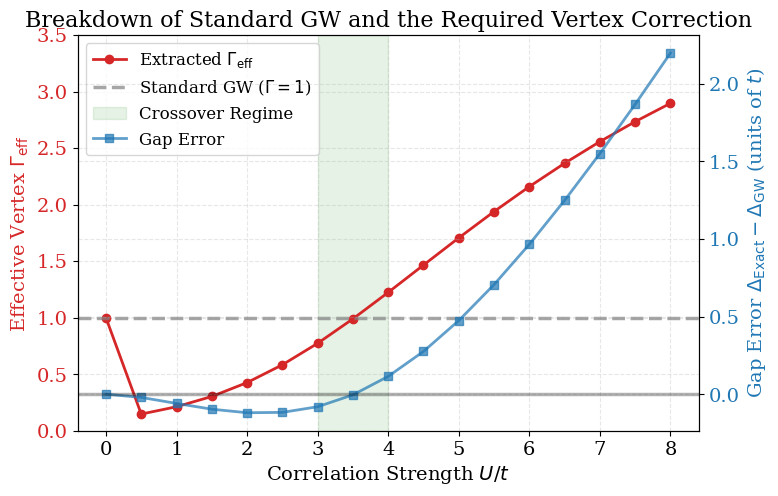

In [9]:
# ---- quick look: Gamma_eff and gap error vs U (data from the previous cell, no pasted numbers) --------
U_t       = U_scan
Gamma_eff = gamma_scan
Diff      = exact_scan - gw_scan

fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot Gamma_eff
color = 'tab:red'
ax1.set_xlabel('Correlation Strength $U/t$', fontsize=14)
ax1.set_ylabel('Effective Vertex $\\Gamma_{\\mathrm{eff}}$', color=color, fontsize=14)
ax1.plot(U_t, Gamma_eff, 'o-', color=color, linewidth=2, markersize=6, label='Extracted $\\Gamma_{\\mathrm{eff}}$')
ax1.axhline(1.0, color='gray', linestyle='--', alpha=0.7, label='Standard GW ($\\Gamma=1$)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0, 3.5)

# Twin axis for the gap error
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Gap Error $\\Delta_{\\mathrm{Exact}} - \\Delta_{\\mathrm{GW}}$ (units of $t$)', color=color, fontsize=14)
ax2.plot(U_t, Diff, 's-', color=color, linewidth=2, markersize=6, alpha=0.7, label='Gap Error')
ax2.tick_params(axis='y', labelcolor=color)
ax2.axhline(0.0, color='black', linestyle='-', alpha=0.3)

# Highlight the crossover region
ax1.axvspan(3.0, 4.0, color='green', alpha=0.1, label='Crossover Regime')

fig.tight_layout()
plt.title('Breakdown of Standard GW and the Required Vertex Correction', fontsize=16)
plt.grid(True, alpha=0.3)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')
plt.show()

In [10]:
# ---- crossover points U* where the static GW gap is exact, for V/t = 0, 0.5, 1.0 --------------------
N, t = 6, 1.0
chi0, occ = get_chi0_static(N, t)

print(f"{'V/t':>5} | {'Crossover 1 (U*)':>16} | {'Crossover 2 (U*)':>16}")
print("-" * 45)
for V in [0.0, 0.5, 1.0]:
    def obj(U):
        return get_exact_gap(N, t, U, V) - get_gw_gap(N, t, U, V, chi0, occ)

    # sweep to bracket the sign changes
    U_sweep = np.linspace(0.1, 8.0, 50)
    vals = [obj(u) for u in U_sweep]
    roots = []
    for i in range(len(U_sweep) - 1):
        if vals[i] * vals[i + 1] <= 0:
            try:
                r = root_scalar(obj, bracket=[U_sweep[i], U_sweep[i + 1]])
                if r.converged: roots.append(r.root)
            except ValueError:
                pass
    cols = [f"{r:16.4f}" for r in roots[:2]] + [f"{'None':>16}"] * (2 - len(roots[:2]))
    print(f"{V:5.1f} | {cols[0]} | {cols[1]}")

  V/t | Crossover 1 (U*) | Crossover 2 (U*)
---------------------------------------------


  0.0 |           3.5228 |             None


  0.5 |           0.7172 |           1.0420


  1.0 |           0.7685 |           1.4666


Saved fig1_gap.pdf
Saved fig2_channel.pdf


Saved fig3_gamma_eff.pdf


Saved fig4_V_crossover.pdf

All main-text figures generated successfully as vector PDFs!


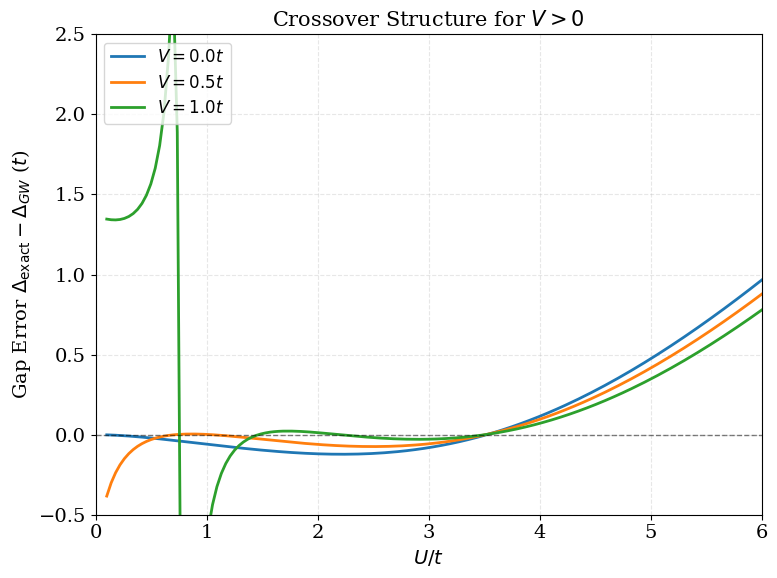

In [11]:
# ---- main-text figures 1-4 (all data computed live; PRB style is set in the imports cell) ---------------
N, t, V = 6, 1.0, 0.0
chi0, occ = get_chi0_static(N, t)

U_disc    = np.arange(0.0, 9.0)                                            # U/t = 0, 1, ..., 8
exact_6   = np.array([get_exact_gap(N, t, U, V) for U in U_disc])
gw_6      = np.array([get_gw_gap(N, t, U, V, chi0, occ) for U in U_disc])
gamma_6   = np.array([find_Gamma_eff(N, t, U, V, chi0, occ, ex) for U, ex in zip(U_disc, exact_6)])
gw_ladder = np.array([get_gw_gap(N, t, U, V, get_chi_ladder(N, t, U), occ) for U in U_disc])
gw_local  = np.array([get_ladder_vertex_B_gap(N, t, U) for U in U_disc])

# ==========================================
# FIGURE 1: Exact vs GW Gap
# ==========================================
fig1, ax1 = plt.subplots(figsize=(8, 6))
ax1.plot(U_disc, exact_6, 'o-', color='tab:red', label='Exact ED')
ax1.plot(U_disc, gw_6, 's--', color='tab:blue', label=r'Static $G_0W_0$ (COHSEX)')

ax1.set_xlabel(r'Correlation Strength $U/t$')
ax1.set_ylabel(r'Fundamental Gap $\Delta/t$')
ax1.set_title('Quasiparticle Gap: Exact vs static COHSEX')
ax1.legend(loc='upper left')
ax1.set_xlim(0, 8)
ax1.set_ylim(0, 6)

# Inset for relative error
axins = ax1.inset_axes([0.55, 0.15, 0.4, 0.4])
axins.plot(U_disc[1:], (exact_6[1:] - gw_6[1:]) / exact_6[1:] * 100, 'x-', color='tab:gray')
axins.set_xlabel(r'$U/t$', fontsize=12)
axins.set_ylabel(r'Rel. Error (%)', fontsize=12)
axins.set_title('Relative Error', fontsize=12)
axins.set_xlim(1, 8)
axins.tick_params(labelsize=10)
ax1.indicate_inset_zoom(axins)

plt.tight_layout()
plt.savefig('fig1_gap.pdf', format='pdf')
plt.close()
print("Saved fig1_gap.pdf")

# ==========================================
# FIGURE 2: Channel Analysis
# ==========================================
fig2, ax2 = plt.subplots(figsize=(8, 6))
ax2.plot(U_disc, exact_6, 'ko-', label='Exact ED', markersize=10)
ax2.plot(U_disc, gw_ladder, '^-', color='tab:green', label=r'$GW$ + Ladder in $W$')
ax2.plot(U_disc, gw_local, 'v-', color='tab:purple', label=r'$GW$ + Local Vertex in $\Sigma$')

ax2.set_xlabel(r'Correlation Strength $U/t$')
ax2.set_ylabel(r'Fundamental Gap $\Delta/t$')
ax2.set_title('Channel-Resolved Vertex Corrections')
ax2.legend(loc='upper left')
ax2.set_xlim(0, 8)
ax2.set_ylim(0, 12)
ax2.annotate('Fails to open\nMott gap', xy=(7, 2.6), xytext=(5, 1.5),
             arrowprops=dict(arrowstyle='->', color='green'), fontsize=12, color='green')
ax2.annotate('Overcorrects\n(static limit)', xy=(7, 10.5), xytext=(4, 8),
             arrowprops=dict(arrowstyle='->', color='purple'), fontsize=12, color='purple')

plt.tight_layout()
plt.savefig('fig2_channel.pdf', format='pdf')
plt.close()
print("Saved fig2_channel.pdf")

# ==========================================
# FIGURE 3: Effective Vertex Gamma_eff
# ==========================================
fig3, ax3_1 = plt.subplots(figsize=(8, 6))
color1 = 'tab:red'
ax3_1.set_xlabel(r'Correlation Strength $U/t$')
ax3_1.set_ylabel(r'Effective Vertex $\Gamma_{\mathrm{eff}}$', color=color1)
ax3_1.plot(U_disc, gamma_6, 'o-', color=color1, label=r'$\Gamma_{\mathrm{eff}}$')
ax3_1.axhline(1.0, color='gray', linestyle='--', linewidth=2, label=r'Standard $GW$ ($\Gamma=1$)')
ax3_1.tick_params(axis='y', labelcolor=color1)
ax3_1.set_ylim(0, 3.5)
ax3_1.set_xlim(0, 8)
ax3_1.legend(loc='upper left', bbox_to_anchor=(0, 0.85))

# Twin axis for Gap Error
ax3_2 = ax3_1.twinx()
color2 = 'tab:blue'
ax3_2.set_ylabel(r'Gap Error $\Delta_{\mathrm{Exact}} - \Delta_{\mathrm{GW}}$ (units of $t$)', color=color2)
ax3_2.plot(U_disc, exact_6 - gw_6, 's-', color=color2, label='Gap Error')
ax3_2.tick_params(axis='y', labelcolor=color2)
ax3_2.axhline(0.0, color='black', linestyle='-', alpha=0.3)
ax3_2.legend(loc='upper left', bbox_to_anchor=(0, 0.7))

# Highlight crossover
ax3_1.axvspan(3.0, 4.0, color='yellow', alpha=0.2, label='Accidental Crossover')
ax3_1.annotate(r'$U^* \approx 3.5 t$', xy=(3.5, 1.0), xytext=(1.5, 2.0),
               arrowprops=dict(arrowstyle='->', color='black'), fontsize=14)
ax3_1.legend(loc='upper left', bbox_to_anchor=(0.05, 0.5))

plt.tight_layout()
plt.savefig('fig3_gamma_eff.pdf', format='pdf')
plt.close()
print("Saved fig3_gamma_eff.pdf")

# ==========================================
# FIGURE 4: V-Crossover
# ==========================================
U_dense  = np.linspace(0.1, 8, 200)
V_values = [0.0, 0.5, 1.0]

plt.figure(figsize=(8, 6))
for Vv in V_values:
    gap_errors = [get_exact_gap(N, t, U, Vv) - get_gw_gap(N, t, U, Vv, chi0, occ) for U in U_dense]
    plt.plot(U_dense, gap_errors, lw=2, label=f'$V={Vv}t$')

plt.axhline(0, color='k', ls='--', lw=1, alpha=0.5)
plt.xlabel('$U/t$', fontsize=14)
plt.ylabel(r'Gap Error $\Delta_{\mathrm{exact}} - \Delta_{GW}$ ($t$)', fontsize=14)
plt.title('Crossover Structure for $V>0$', fontsize=15)
plt.legend(fontsize=12, loc='upper left')
plt.xlim(0, 6)
plt.ylim(-0.5, 2.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig4_V_crossover.pdf', format='pdf')
print("Saved fig4_V_crossover.pdf")

print("\nAll main-text figures generated successfully as vector PDFs!")

## ready for submission

## after review

PH symmetry of exact G_loc: max|G(w) + conj G(-w)| = 5.5013763429590855e-14


Sigma(w)+Sigma(-w) identity residual = 2.2515322939398175e-13


Saved fig_sigma_exact.pdf


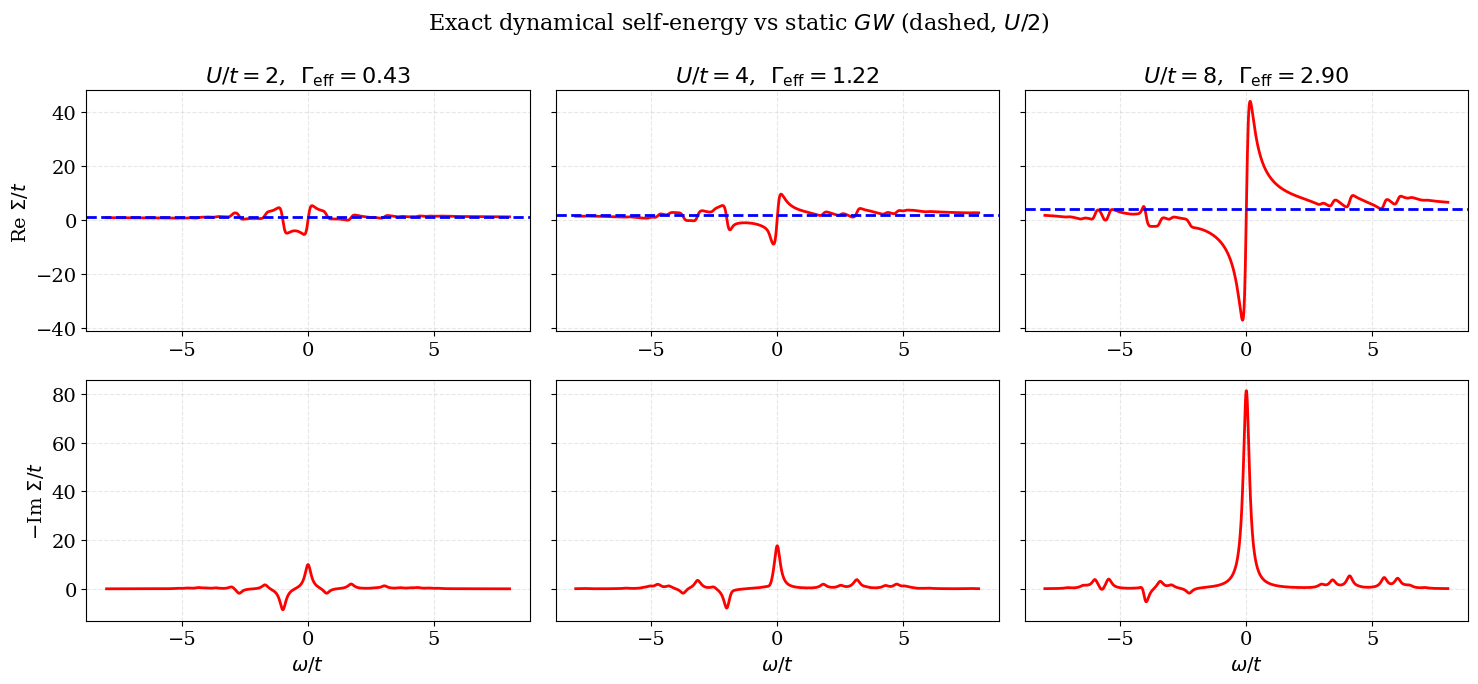

In [12]:
# ---- exact local self-energy Sigma(omega): validation + figure -----------------------------------------
N, t = 6, 1.0
eta  = 0.15

# --- validation on a frequency grid that is exactly symmetric (contains +-3 and +-8) ---
U_chk, mu = 4.0, 2.0                                   # mu = U/2 (half filling)
omega_chk = np.linspace(-8, 8, 801)
_, Gk = get_lehmann_G(N, t, U_chk, omega_chk + mu, eta)
G_loc = Gk.mean(axis=0)
# (1) exact particle-hole symmetry about mu:  G(mu + w) = -conj G(mu - w)   -> residual ~ 1e-13
print("PH symmetry of exact G_loc: max|G(w) + conj G(-w)| =", np.max(np.abs(G_loc + np.conj(G_loc[::-1]))))
# (2) consequently Sigma(w) + Sigma(-w) = 1/G0(mu+w) + 1/G0(mu-w) (NOT U at finite w)   -> residual ~ 1e-13
Sig_chk = compute_sigma_local(N, t, U_chk, omega_chk, eta)
R0 = lambda z: 1.0 / np.mean([1.0 / (z - e + 1j * eta) for e in get_eps_k(N, t)], axis=0)
print("Sigma(w)+Sigma(-w) identity residual =",
      np.max(np.abs((Sig_chk + Sig_chk[::-1]).real - (R0(omega_chk + mu) + R0(mu - omega_chk)).real)))

# --- figure: exact Sigma(omega) vs static GW (dashed, U/2) for U/t = 2, 4, 8 ---
omega = np.linspace(-8, 8, 1000)
chi0, occ = get_chi0_static(N, t)

fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharey='row')
for col, Uv in enumerate([2.0, 4.0, 8.0]):
    gv = find_Gamma_eff(N, t, Uv, 0.0, chi0, occ, get_exact_gap(N, t, Uv, 0.0))
    S = compute_sigma_local(N, t, Uv, omega, eta)
    axes[0, col].plot(omega, np.real(S), 'r-', lw=2)
    axes[0, col].axhline(Uv / 2, color='b', ls='--', lw=2)
    axes[0, col].set_title(f'$U/t={Uv:.0f}$,  $\\Gamma_{{\\rm eff}}={gv:.2f}$')
    axes[1, col].plot(omega, -np.imag(S), 'r-', lw=2)

axes[0, 0].set_ylabel('Re $\\Sigma/t$', fontsize=14)
axes[1, 0].set_ylabel('$-$Im $\\Sigma/t$', fontsize=14)
for ax in axes[1]: ax.set_xlabel('$\\omega/t$', fontsize=14)
fig.suptitle('Exact dynamical self-energy vs static $GW$ (dashed, $U/2$)', fontsize=16)
plt.tight_layout()
plt.savefig('fig_sigma_exact.pdf', format='pdf')
print("Saved fig_sigma_exact.pdf")

Computing U=0...
Computing U=4...
Computing U=8...


Successfully saved spectral_functions_final.png


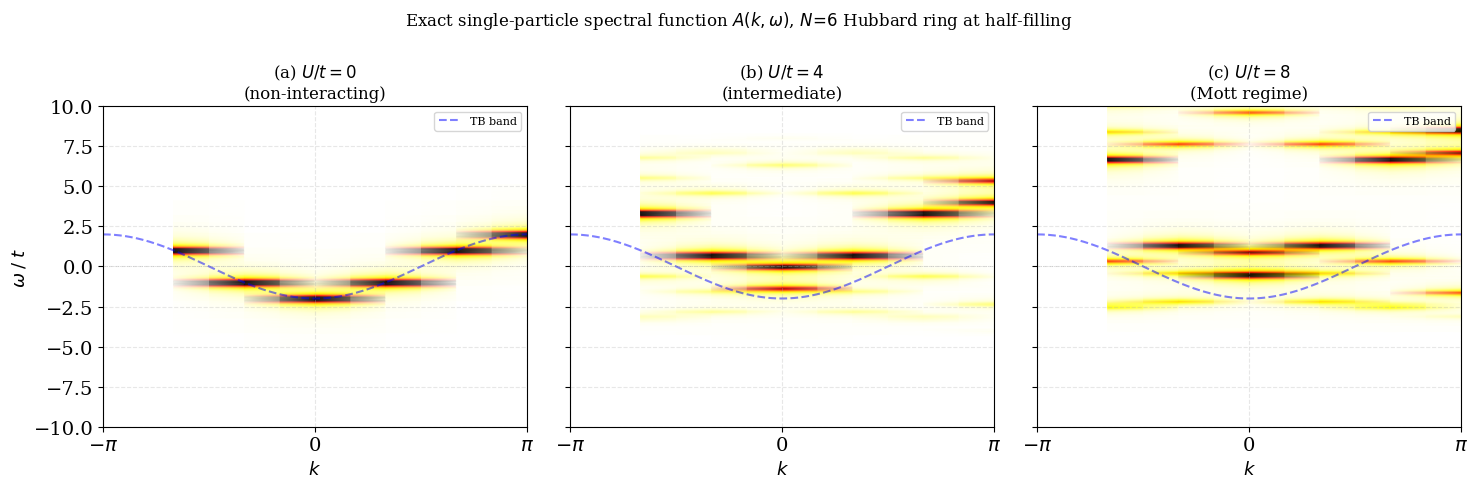

In [13]:
# ---- exact spectral function A(k, omega) for U/t = 0, 4, 8 --------------------------------------------
N, t = 6, 1.0
eta = 0.15
omega_wide = np.linspace(-12, 12, 500)                 # wide window to capture the upper Hubbard band at U = 8
U_list = (0.0, 4.0, 8.0)

A_wide = {}
for U in U_list:
    print(f"Computing U={U:g}...")
    k_v, A_wide[U] = compute_Ak(N, t, U, omega_wide, eta)

# Sort k-points from -pi to pi
k_wrapped = np.where(k_v > np.pi + 1e-10, k_v - 2 * np.pi, k_v)
k_order   = np.argsort(k_wrapped)
k_sorted  = k_wrapped[k_order]

# Tight-binding reference band
k_dense = np.linspace(-np.pi, np.pi, 300)
eps_tb  = -2 * t * np.cos(k_dense)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
all_A = [A_wide[U][k_order] for U in U_list]
titles = ['(a) $U/t = 0$\n(non-interacting)', '(b) $U/t = 4$\n(intermediate)', '(c) $U/t = 8$\n(Mott regime)']
vmax_vals = [2.5, 2.0, 1.5]                            # per-panel colour scale

for ax, A_s, title, vm in zip(axes, all_A, titles, vmax_vals):
    im = ax.pcolormesh(k_sorted, omega_wide, A_s.T, shading='gouraud', cmap='hot_r', vmin=0, vmax=vm)
    ax.plot(k_dense, eps_tb, 'b--', alpha=0.5, lw=1.5, label='TB band')
    ax.axhline(0, color='gray', lw=0.5, alpha=0.5, ls=':')
    ax.set_xlabel('$k$', fontsize=13)
    ax.set_title(title, fontsize=12)
    ax.set_xlim(-np.pi, np.pi)
    ax.set_ylim(-10, 10)
    ax.set_xticks([-np.pi, 0, np.pi])
    ax.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
    ax.legend(fontsize=8, loc='upper right')

axes[0].set_ylabel(r'$\omega\;/\;t$', fontsize=13)
fig.suptitle(r'Exact single-particle spectral function $A(k,\omega)$, $N\!=\!6$ Hubbard ring at half-filling', fontsize=12)
fig.tight_layout()
plt.savefig('spectral_functions_final.png', dpi=200, bbox_inches='tight')
print("Successfully saved spectral_functions_final.png")
plt.show()

### full freq GW

In [14]:
# ---- full-frequency G0W0 for the N = 6 ring (charge channel) ------------------------------------
# KNOWN ISSUE (not fixed ): the G0W0(full-w) column is exactly 2.0000
# for every U, i.e. Sigma_c ~ 1e-4 (numerically zero). get_sigma_c_k convolves a *retarded* G0 with a *retarded* W
# (both analytic in the upper half plane), and that frequency integral vanishes by contour closure. A non-zero
# Sigma_c needs the time-ordered G0 and W (poles on both sides of the real axis).
# NOTE on convention (unchanged from the original cell): the dynamic charge-channel screening uses
#     eps_c(z) = 1 - Uc * chi0_summed(z),  Uc = U/2,
# so its static limit equals get_gw_gap(..., Uc, ...) -- i.e. the COHSEX column below is the static-cell
# COHSEX gap evaluated at U/2, NOT at U.  Set Uc = U to use the same convention as the static cells.

def get_chi0_dynamic(N, t, z):
    """Per-spin chi0(z) in the site basis (spin-summed chi = 2 * this)."""
    k, eps = get_k_vals(N), get_eps_k(N, t)
    occ = get_occ(N, t)
    virt = [c for c in range(N) if c not in occ]
    chi = np.zeros((N, N), dtype=complex)
    for v in occ:
        for c in virt:
            D = eps[c] - eps[v]
            rv = np.exp(1j * (k[v] - k[c]) * np.arange(N)) / N          # phi_v(i) conj(phi_c(i))
            chi += np.outer(rv, np.conj(rv)) * (1.0 / (z - D) - 1.0 / (z + D))
    return chi


def get_G0_site(N, t, z):
    """Non-interacting G0(z) in the site basis."""
    k, eps = get_k_vals(N), get_eps_k(N, t)
    G = np.zeros((N, N), dtype=complex)
    for ik in range(N):
        fk = np.exp(1j * k[ik] * np.arange(N)) / np.sqrt(N)
        G += np.outer(fk, np.conj(fk)) / (z - eps[ik])
    return G


def get_W_ind(N, t, Uc, z):
    """Induced screened interaction W(z) - v, charge channel with coupling Uc."""
    vc = Uc * np.eye(N)
    eps_c = np.eye(N) - vc @ (2 * get_chi0_dynamic(N, t, z))
    return np.linalg.solve(eps_c, vc) - vc


def get_sigma_c_k(N, t, Uc, eta, wgrid, wlist):
    """Diagonal-in-k Sigma_c(omega + i eta) on the frequency list `wlist` (dict: omega -> array over k)."""
    Wind = [get_W_ind(N, t, Uc, w + 1j * eta) for w in wgrid]
    dw = wgrid[1] - wgrid[0]
    k = get_k_vals(N)
    F = [np.exp(1j * k[ik] * np.arange(N)) / np.sqrt(N) for ik in range(N)]
    out = {}
    for w in wlist:
        Sk = np.zeros(N, dtype=complex)
        for iw, wp in enumerate(wgrid):
            Sij = (1j / (2 * np.pi)) * get_G0_site(N, t, w + wp + 1j * eta) * Wind[iw]   # elementwise, site basis
            for ik in range(N):
                Sk[ik] += np.vdot(F[ik], Sij @ F[ik]) * dw
        out[w] = Sk
    return out


def get_qp_gap_fullw(N, t, Uc, eta, wgrid, wlist, k_homo=1, k_lumo=2):
    """Full-frequency G0W0 gap from the fixed-point Re Sigma_c(k, eps_k) at the HOMO / LUMO k-points."""
    eps = get_eps_k(N, t)
    Sk = get_sigma_c_k(N, t, Uc, eta, wgrid, wlist)
    def Sig_k(k, w):                                   # linear interpolation on wlist
        i = np.clip(np.searchsorted(wlist, w) - 1, 0, len(wlist) - 2)
        f = (w - wlist[i]) / (wlist[i + 1] - wlist[i])
        return (1 - f) * Sk[wlist[i]][k] + f * Sk[wlist[i + 1]][k]
    def solve(k):
        e = eps[k]
        for _ in range(8):
            e = eps[k] + np.real(Sig_k(k, e))
        return e
    return solve(k_lumo) - solve(k_homo)


# ---- run ---------------------------------------------------------------------------------------
N, t, V = 6, 1.0, 0.0
eta_ff = 0.1
wgrid  = np.linspace(-50, 50, 2001)
wlist  = np.linspace(-6, 6, 81)
chi0, occ = get_chi0_static(N, t)

print(f"{'U/t':>4} | {'ED':>7} | {'COHSEX(Uc)':>10} | {'G0W0(full-w)':>12}")
for U in [2, 4, 6, 8]:
    Uc = U / 2.0                                       # charge-channel coupling (see note above)
    ed   = get_exact_gap(N, t, U, V)
    coh  = get_gw_gap(N, t, Uc, 0.0, chi0, occ)
    fw   = get_qp_gap_fullw(N, t, Uc, eta_ff, wgrid, wlist)
    print(f"{U:4.0f} | {ed:7.4f} | {coh:10.4f} | {fw:12.4f}")

 U/t |      ED | COHSEX(Uc) | G0W0(full-w)


   2 |  2.0887 |     2.0758 |       2.0000


   4 |  2.6275 |     2.2083 |       2.0000


   6 |  3.7994 |     2.3571 |       2.0000


   8 |  5.3581 |     2.5128 |       2.0000


## first submission --here. 

## resubmission work

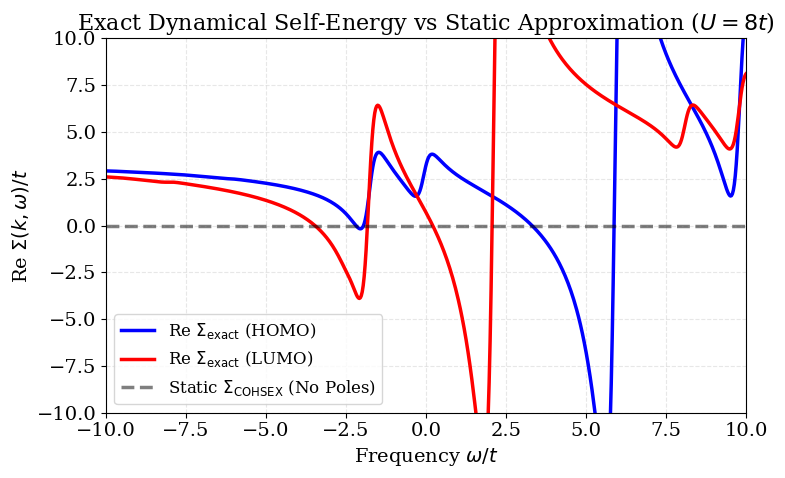

In [15]:
# ---- exact k-resolved self-energy at U = 8t: HOMO (k = pi/3) and LUMO (k = 2pi/3) ------------------------
N, U, t = 6, 8.0, 1.0
omega = np.linspace(-15, 15, 1000)
k_vals, Sigma_exact = compute_sigma_k(N, t, U, omega, eta=0.3)

fig, ax = plt.subplots(figsize=(8, 5))
k_HOMO, k_LUMO = np.pi / 3, 2 * np.pi / 3
idx_HOMO = np.argmin(np.abs(k_vals - k_HOMO))
idx_LUMO = np.argmin(np.abs(k_vals - k_LUMO))

ax.plot(omega, np.real(Sigma_exact[idx_HOMO]), label=r'Re $\Sigma_{\text{exact}}$ (HOMO)', color='blue')
ax.plot(omega, np.real(Sigma_exact[idx_LUMO]), label=r'Re $\Sigma_{\text{exact}}$ (LUMO)', color='red')

# COHSEX static self-energy for comparison: a frequency-independent line (no poles)
ax.axhline(0, color='black', linestyle='--', alpha=0.5, label=r'Static $\Sigma_{\text{COHSEX}}$ (No Poles)')

ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
ax.set_xlabel(r'Frequency $\omega / t$', fontsize=14)
ax.set_ylabel(r'Re $\Sigma(k, \omega) / t$', fontsize=14)
ax.set_title(r'Exact Dynamical Self-Energy vs Static Approximation ($U=8t$)', fontsize=16)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_sigma_kU8.pdf', format='pdf')
plt.show()

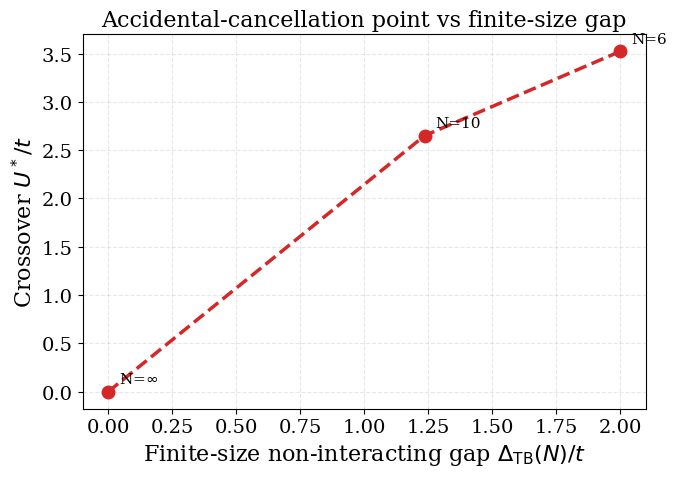

In [ ]:
# ---- finite-size scaling of the crossover U*: closed-shell rings only (N = 2 mod 4); N = 8, 12 are open-shell ----
# NOTE: N = 10 uses sparse Lanczos on sectors of dimension ~6e4 and takes a few minutes.
t, V = 1.0, 0.0
N_vals = [6, 10]
DTB, Ustar = [], []
for N in N_vals:
    chi0, occ = get_chi0_static(N, t)
    f = lambda U: get_exact_gap(N, t, U, V) - get_gw_gap(N, t, U, V, chi0, occ)
    Ustar.append(brentq(f, 1.5, 7.0, xtol=1e-3))
    DTB.append(get_tb_gap(N, t))
    print(f"N={N:2d}:  Delta_TB = {DTB[-1]:.4f},  U* = {Ustar[-1]:.4f}")

# thermodynamic-limit endpoint (Delta_TB -> 0, U* -> 0)
DTB.append(0.0); Ustar.append(0.0)

plt.figure(figsize=(7, 5))
plt.plot(DTB, Ustar, 'o--', color='tab:red', ms=9)
for x, y, N in zip(DTB, Ustar, N_vals + [r'$\infty$']):
    plt.annotate(f'N={N}', (x, y), textcoords='offset points', xytext=(8, 6), fontsize=11)
plt.xlabel(r'Finite-size non-interacting gap $\Delta_{\rm TB}(N)/t$')
plt.ylabel(r'Crossover $U^*/t$')
plt.title('Accidental-cancellation point vs finite-size gap')
plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('fig_scaling_without_14.pdf'); plt.show()

# N14

In [9]:
import numpy as np
import itertools
from scipy.sparse import coo_matrix
from scipy.sparse.linalg import eigsh
from scipy.optimize import brentq
import time

# ==========================================
# 1. VECTORIZED SPARSE BUILDER (N=14 optimized)
# ==========================================
def build_templates(N, n_up, n_down, t=1.0):
    """Pre-computes the sparse matrix structure (rows, cols, hopping signs) for a given sector."""
    ups = np.array([sum(1<<b for b in c) for c in itertools.combinations(range(N), n_up)], dtype=np.int64)
    downs = np.array([sum(1<<b for b in c) for c in itertools.combinations(range(N), n_down)], dtype=np.int64)
    st = (ups[:, None] | (downs[None, :] << N)).ravel()
    st.sort()
    dim = st.size
    
    up = st & ((1 << N) - 1)
    dn = st >> N
    
    # Diagonal masks (Double occupancy and NN interaction)
    D_mask = np.zeros(dim, dtype=np.float64)
    for i in range(N): D_mask += ((up >> i) & 1) * ((dn >> i) & 1)
    NN_mask = np.zeros(dim, dtype=np.float64)
    for i in range(N):
        j = (i + 1) % N
        NN_mask += (((up >> i) & 1) + ((dn >> i) & 1)) * (((up >> j) & 1) + ((dn >> j) & 1))
        
    # Parity lookup for fermion signs (fast bitwise operations)
    PC = np.array([bin(i).count('1') for i in range(1 << 16)], dtype=np.int8)
    def parity(x): return (PC[x & 0xFFFF] ^ PC[(x >> 16) & 0xFFFF]) & 1

    rows_list, cols_list, t_vals_list = [], [], []
    directed = [(i, (i+1)%N) for i in range(N)] + [((i+1)%N, i) for i in range(N)]
    
    for spin in range(2):
        mask = up if spin == 0 else dn
        other = dn if spin == 0 else up
        for a, b in directed:
            valid = (((mask >> a) & 1) & (1 - ((mask >> b) & 1))).astype(bool)
            if not valid.any(): continue
            new_mask = mask[valid] ^ (1 << a) ^ (1 << b)
            new_st = new_mask | (other[valid] << N) if spin == 0 else up[valid] | (new_mask << N)
            idx = np.searchsorted(st, new_st)
            
            pa, pb = a + spin * N, b + spin * N
            lo, hi = min(pa, pb), max(pa, pb)
            w = hi - lo - 1
            if w > 0:
                sign = 1 - 2 * parity(st[valid] & (((1 << w) - 1) << (lo + 1)))
            else:
                sign = np.ones(valid.sum(), dtype=np.int8)
                
            rows_list.append(idx); cols_list.append(np.where(valid)[0]); t_vals_list.append(-t * sign)

    rows_off = np.concatenate(rows_list); cols_off = np.concatenate(cols_list)
    t_vals_off = np.concatenate(t_vals_list).astype(np.float64)
    r_diag = np.arange(dim)
    
    return {
        'dim': dim, 'D_mask': D_mask, 'NN_mask': NN_mask,
        'rows': np.concatenate([rows_off, r_diag]), 
        'cols': np.concatenate([cols_off, r_diag]), 
        't_vals': t_vals_off
    }

def get_E0(templ, U, V):
    """Instantiates the CSR matrix and runs Lanczos (eigsh) in seconds."""
    diag = U * templ['D_mask'] + V * templ['NN_mask']
    vals = np.concatenate([templ['t_vals'], diag])
    H = coo_matrix((vals, (templ['rows'], templ['cols'])), shape=(templ['dim'], templ['dim'])).tocsr()
    return eigsh(H, k=1, which='SA', return_eigenvectors=False, tol=1e-8)[0]

# ==========================================
# 2. BUILD TEMPLATES (Takes ~30-45 seconds)
# ==========================================
N = 14
print(f"Building sparse templates for N={N}... (This happens only once)")
t0 = time.time()
# N=14 (7,7), N=13 (7,6), N=15 (8,7)
templ_N   = build_templates(N, N//2, N//2)
templ_Nm1 = build_templates(N, (N-1+1)//2, (N-1)//2)
templ_Np1 = build_templates(N, (N+1+1)//2, (N+1)//2)
print(f"Templates built in {time.time()-t0:.1f} seconds. Matrix dimension: {templ_N['dim']:,}")

def gap_error_N14(U):
    Em = get_E0(templ_Nm1, U, 0.0)
    E0 = get_E0(templ_N, U, 0.0)
    Ep = get_E0(templ_Np1, U, 0.0)
    exact_gap = Em + Ep - 2 * E0
    
    # GW gap is just 14x14 linear algebra, takes microseconds
    chi0, occ = get_chi0_static(N, 1.0)
    gw_gap = get_gw_gap(N, 1.0, U, 0.0, chi0, occ, 1.0)
    return exact_gap - gw_gap

# ==========================================
# 3. RUN THE SWEEP & ROOT FINDING
# ==========================================
print("\nSweeping U to find bracket...")
U_sweep = np.linspace(0.5, 4.0, 15) # Focus on the expected crossover region
vals = []
for u in U_sweep:
    t1 = time.time()
    val = gap_error_N14(u)
    vals.append(val)
    print(f"  U={u:.2f} | Gap Error = {val:+.4f} | (took {time.time()-t1:.1f}s)")

U_star14 = np.nan
for i in range(len(U_sweep)-1):
    if vals[i] * vals[i+1] <= 0:
        print(f"\nFound bracket: [{U_sweep[i]:.2f}, {U_sweep[i+1]:.2f}]. Running Brentq...")
        U_star14 = brentq(gap_error_N14, U_sweep[i], U_sweep[i+1], xtol=1e-3)
        break

print(f"\n*** FINAL RESULT: U*(14) = {U_star14:.4f} ***")

# Get Gamma_eff at U=8
print("Calculating Gamma_eff at U=8...")
gap_exact_8 = get_E0(templ_Nm1, 8.0, 0.0) + get_E0(templ_Np1, 8.0, 0.0) - 2*get_E0(templ_N, 8.0, 0.0)
chi0_14, occ_14 = get_chi0_static(N, 1.0)
gamma_8 = brentq(lambda g: get_gw_gap(N, 1.0, 8.0, 0.0, chi0_14, occ_14, g) - gap_exact_8, 0.1, 40.0)
print(f"*** Gamma_eff(U=8, N=14) = {gamma_8:.4f} ***")

Building sparse templates for N=14... (This happens only once)
Templates built in 75.7 seconds. Matrix dimension: 11,778,624

Sweeping U to find bracket...
  U=0.50 | Gap Error = -0.0111 | (took 151.7s)
  U=0.75 | Gap Error = -0.0201 | (took 148.8s)
  U=1.00 | Gap Error = -0.0289 | (took 149.3s)
  U=1.25 | Gap Error = -0.0357 | (took 159.4s)
  U=1.50 | Gap Error = -0.0388 | (took 176.9s)
  U=1.75 | Gap Error = -0.0359 | (took 171.6s)
  U=2.00 | Gap Error = -0.0246 | (took 196.4s)
  U=2.25 | Gap Error = -0.0021 | (took 194.5s)
  U=2.50 | Gap Error = +0.0339 | (took 175.2s)
  U=2.75 | Gap Error = +0.0856 | (took 189.7s)
  U=3.00 | Gap Error = +0.1542 | (took 203.8s)
  U=3.25 | Gap Error = +0.2398 | (took 218.6s)
  U=3.50 | Gap Error = +0.3415 | (took 203.2s)
  U=3.75 | Gap Error = +0.4580 | (took 211.2s)
  U=4.00 | Gap Error = +0.5876 | (took 224.4s)

Found bracket: [2.25, 2.50]. Running Brentq...

*** FINAL RESULT: U*(14) = 2.2683 ***
Calculating Gamma_eff at U=8...
*** Gamma_eff(U=8, N

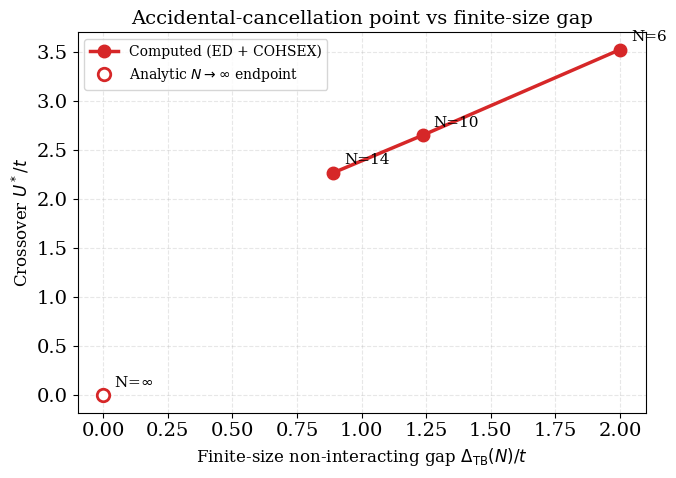

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Data from your runs
N_vals = [6, 10, 14]
DTB = [2.0000, 1.2361, 0.8901]  # 4*sin(pi/N)
Ustar = [3.5228, 2.6504, 2.2683]

# Add thermodynamic limit endpoint
DTB.append(0.0)
Ustar.append(0.0)

plt.figure(figsize=(7, 5))
# Plot computed points
plt.plot(DTB[:3], Ustar[:3], 'o-', color='tab:red', ms=9, label='Computed (ED + COHSEX)')
# Plot analytic endpoint as an open marker
plt.plot(DTB[3], Ustar[3], 'o', color='tab:red', ms=9, markerfacecolor='white', markeredgewidth=2, label=r'Analytic $N\to\infty$ endpoint')

for x, y, N in zip(DTB, Ustar, N_vals + [r'$\infty$']):
    plt.annotate(f'N={N}', (x, y), textcoords='offset points', xytext=(8, 6), fontsize=11)

plt.xlabel(r'Finite-size non-interacting gap $\Delta_{\rm TB}(N)/t$', fontsize=12)
plt.ylabel(r'Crossover $U^*/t$', fontsize=12)
plt.title('Accidental-cancellation point vs finite-size gap', fontsize=14)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_scaling.pdf')
plt.show()

## table

In [11]:
import numpy as np
import itertools
from scipy.sparse import coo_matrix
from scipy.sparse.linalg import eigsh
from scipy.optimize import brentq
import time

# ==========================================
# 1. VECTORIZED SPARSE BUILDER (N=14 optimized)
# ==========================================
def build_templates(N, n_up, n_down, t=1.0):
    ups = np.array([sum(1<<b for b in c) for c in itertools.combinations(range(N), n_up)], dtype=np.int64)
    downs = np.array([sum(1<<b for b in c) for c in itertools.combinations(range(N), n_down)], dtype=np.int64)
    st = (ups[:, None] | (downs[None, :] << N)).ravel()
    st.sort()
    dim = st.size
    up = st & ((1 << N) - 1)
    dn = st >> N
    D_mask = np.zeros(dim, dtype=np.float64)
    for i in range(N): D_mask += ((up >> i) & 1) * ((dn >> i) & 1)
    NN_mask = np.zeros(dim, dtype=np.float64)
    for i in range(N):
        j = (i + 1) % N
        NN_mask += (((up >> i) & 1) + ((dn >> i) & 1)) * (((up >> j) & 1) + (((dn >> j) & 1)))
    PC = np.array([bin(i).count('1') for i in range(1 << 16)], dtype=np.int8)
    def parity(x): return (PC[x & 0xFFFF] ^ PC[(x >> 16) & 0xFFFF]) & 1
    rows_list, cols_list, t_vals_list = [], [], []
    directed = [(i, (i+1)%N) for i in range(N)] + [((i+1)%N, i) for i in range(N)]
    for spin in range(2):
        mask = up if spin == 0 else dn
        other = dn if spin == 0 else up
        for a, b in directed:
            valid = (((mask >> a) & 1) & (1 - ((mask >> b) & 1))).astype(bool)
            if not valid.any(): continue
            new_mask = mask[valid] ^ (1 << a) ^ (1 << b)
            new_st = new_mask | (other[valid] << N) if spin == 0 else up[valid] | (new_mask << N)
            idx = np.searchsorted(st, new_st)
            pa, pb = a + spin * N, b + spin * N
            lo, hi = min(pa, pb), max(pa, pb)
            w = hi - lo - 1
            if w > 0:
                sign = 1 - 2 * parity(st[valid] & (((1 << w) - 1) << (lo + 1)))
            else:
                sign = np.ones(valid.sum(), dtype=np.int8)
            rows_list.append(idx); cols_list.append(np.where(valid)[0]); t_vals_list.append(-t * sign)
    rows_off = np.concatenate(rows_list); cols_off = np.concatenate(cols_list)
    t_vals_off = np.concatenate(t_vals_list).astype(np.float64)
    r_diag = np.arange(dim)
    return {
        'dim': dim, 'D_mask': D_mask, 'NN_mask': NN_mask,
        'rows': np.concatenate([rows_off, r_diag]), 
        'cols': np.concatenate([cols_off, r_diag]), 
        't_vals': t_vals_off
    }

def get_E0(templ, U, V):
    diag = U * templ['D_mask'] + V * templ['NN_mask']
    vals = np.concatenate([templ['t_vals'], diag])
    H = coo_matrix((vals, (templ['rows'], templ['cols'])), shape=(templ['dim'], templ['dim'])).tocsr()
    return eigsh(H, k=1, which='SA', return_eigenvectors=False, tol=1e-8)[0]

# ==========================================
# 2. GW FUNCTIONS
# ==========================================
def get_chi0_static(N, t):
    k = 2 * np.pi * np.arange(N) / N
    eps = -2 * t * np.cos(k)
    order = np.argsort(eps)
    occ = list(order[:N // 2])
    virt = list(order[N // 2:])
    chi = np.zeros((N, N))
    for v in occ:
        for c in virt:
            D = eps[c] - eps[v]
            rv = np.exp(1j * (k[v] - k[c]) * np.arange(N)) / N
            chi += (-4.0 / D) * np.real(np.outer(rv, np.conj(rv)))
    return chi, occ

def get_gw_gap(N, t, U, V, chi, occ=None, Gamma=1.0):
    if occ is None:
        k = 2 * np.pi * np.arange(N) / N
        eps = -2 * t * np.cos(k)
        occ = list(np.argsort(eps)[:N // 2])
    v = np.zeros((N, N))
    for i in range(N):
        v[i, i] = U
        v[i, (i + 1) % N] = V
        v[(i + 1) % N, i] = V
    W = np.linalg.solve(np.eye(N) - v @ chi, v)
    dW = W - v
    k = 2 * np.pi * np.arange(N) / N
    Phi = np.exp(1j * np.outer(np.arange(N), k[occ])) / np.sqrt(N)
    rho0 = np.real(Phi @ Phi.conj().T)
    H = np.zeros((N, N))
    for i in range(N):
        H[i, (i + 1) % N] = -t
        H[(i + 1) % N, i] = -t
    H += -Gamma * dW * rho0
    H[np.diag_indices(N)] += 0.5 * Gamma * np.diag(dW)
    ev = np.sort(np.linalg.eigvalsh(H))
    return ev[N // 2] - ev[N // 2 - 1]

# ==========================================
# 3. RUN THE SWEEP
# ==========================================
N = 14
print(f"Building sparse templates for N={N} Gamma_eff sweep...")
t0 = time.time()
templ_Nm1 = build_templates(N, (N-1+1)//2, (N-1)//2)
templ_N   = build_templates(N, N//2, N//2)
templ_Np1 = build_templates(N, (N+1+1)//2, (N+1)//2)
print(f"Templates built in {time.time()-t0:.1f} seconds.")

chi0_14, occ_14 = get_chi0_static(N, 1.0)

U_sweep = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0]

print(f"\n{'U/t':>6} | {'Exact Gap':>10} | {'Std GW':>10} | {'Gamma_eff':>10}")
print("-" * 45)

results = []
for U in U_sweep:
    t1 = time.time()
    # Exact gap
    Em = get_E0(templ_Nm1, U, 0.0)
    E0 = get_E0(templ_N, U, 0.0)
    Ep = get_E0(templ_Np1, U, 0.0)
    exact_gap = Em + Ep - 2 * E0
    
    # Std GW gap
    std_gw = get_gw_gap(N, 1.0, U, 0.0, chi0_14, occ_14, 1.0)
    
    # Find Gamma_eff
    def obj(gamma):
        return get_gw_gap(N, 1.0, U, 0.0, chi0_14, occ_14, gamma) - exact_gap
    
    try:
        gamma = brentq(obj, 0.01, 20.0, xtol=1e-4)
    except ValueError:
        gamma = np.nan
        
    results.append((U, exact_gap, std_gw, gamma))
    print(f"{U:6.1f} | {exact_gap:10.4f} | {std_gw:10.4f} | {gamma:10.4f}   ({time.time()-t1:.1f}s)")

print("\nSweep complete!")

Building sparse templates for N=14 Gamma_eff sweep...
Templates built in 155.9 seconds.

   U/t |  Exact Gap |     Std GW |  Gamma_eff
---------------------------------------------
   1.0 |     0.8986 |     0.9275 |     0.2279   (177.2s)
   2.0 |     0.9638 |     0.9883 |     0.7501   (183.6s)
   3.0 |     1.2088 |     1.0546 |     1.9376   (207.4s)
   4.0 |     1.7105 |     1.1229 |     3.5234   (236.0s)
   5.0 |     2.3954 |     1.1923 |     4.9805   (262.8s)
   6.0 |     3.1807 |     1.2623 |     6.1537   (289.6s)
   7.0 |     4.0239 |     1.3327 |     7.0807   (333.6s)
   8.0 |     4.9040 |     1.4033 |     7.8217   (342.2s)

Sweep complete!


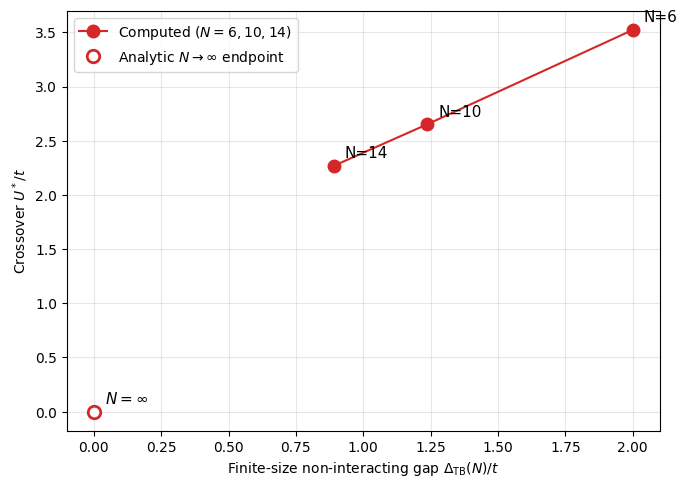

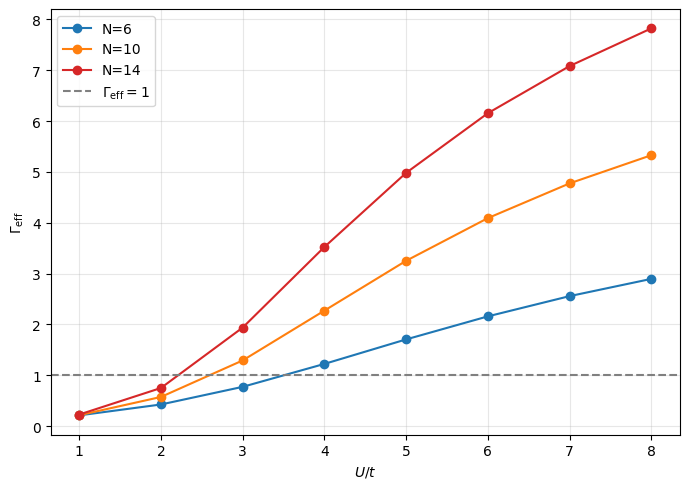

saved fig_scaling.pdf, fig_gamma_N.pdf


In [1]:
import numpy as np, matplotlib.pyplot as plt

N_vals = [6, 10, 14]
DTB    = [2.0000, 1.2361, 0.8901]
Ustar  = [3.5228, 2.6504, 2.2683]
U_arr  = np.array([1,2,3,4,5,6,7,8])
G6  = np.array([0.212,0.426,0.773,1.224,1.706,2.159,2.557,2.896])
G10 = np.array([0.215,0.574,1.292,2.272,3.252,4.091,4.774,5.328])
G14 = np.array([0.228,0.750,1.938,3.523,4.981,6.154,7.081,7.822])

# --- Fig 7: drift of U* ---
plt.figure(figsize=(7,5))
plt.plot(DTB, Ustar, 'o-', color='tab:red', ms=9, label='Computed ($N=6,10,14$)')
plt.plot(0, 0, 'o', color='tab:red', ms=9, mfc='white', mew=2,
         label=r'Analytic $N\to\infty$ endpoint')
for x,y,N in zip(DTB, Ustar, N_vals):
    plt.annotate(f'N={N}', (x,y), textcoords='offset points', xytext=(8,6), fontsize=11)
plt.annotate(r'$N=\infty$', (0,0), textcoords='offset points', xytext=(8,6), fontsize=11)
plt.xlabel(r'Finite-size non-interacting gap $\Delta_{\rm TB}(N)/t$')
plt.ylabel(r'Crossover $U^*/t$'); plt.legend(fontsize=10); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('fig_scaling.pdf'); plt.show() ; plt.close()

# --- New appendix figure: Gamma_eff(U) for three sizes ---
plt.figure(figsize=(7,5))
for G, N, c in zip((G6,G10,G14), N_vals, ('tab:blue','tab:orange','tab:red')):
    plt.plot(U_arr, G, 'o-', color=c, label=f'N={N}')
plt.axhline(1, color='gray', ls='--', lw=1.5, label=r'$\Gamma_{\rm eff}=1$')
plt.xlabel(r'$U/t$'); plt.ylabel(r'$\Gamma_{\rm eff}$')
plt.legend(fontsize=10); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('fig_gamma_N.pdf'); plt.show(); plt.close()

print("saved fig_scaling.pdf, fig_gamma_N.pdf")